In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [2]:
train = pd.read_csv('period_1_train_data.csv')
test = pd.read_csv('test_x.csv')
print(f"Train: {train.shape[0]} строк, {train.shape[1]} колонок")
print(f"Test: {test.shape[0]} строк, {test.shape[1]} колонок")

Train: 29905 строк, 83 колонок
Test: 7477 строк, 83 колонок


Минимум: 15859.265133420433
Максимум: 142207.31560857888
Среднее: 24606.73
Медиана: 22257.19


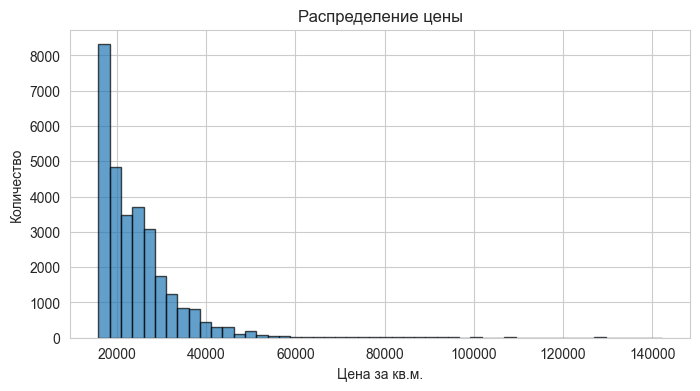

In [3]:
target = train['price_target']
print(f"Минимум: {target.min()}")
print(f"Максимум: {target.max()}")
print(f"Среднее: {target.mean():.2f}")
print(f"Медиана: {target.median():.2f}")

plt.figure(figsize=(8,4))
plt.hist(train['price_target'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Цена за кв.м.')
plt.ylabel('Количество')
plt.title('Распределение цены')
plt.show()

In [4]:
missing_count = train.isnull().sum()
missing_cols = missing_count[missing_count > 0]

if len(missing_cols) > 0:
    print(f"Колонок с пропусками: {len(missing_cols)}")
    print("\nТоп-5 колонок с наибольшим числом пропусков:")
    print(missing_cols.sort_values(ascending=False).head())

Колонок с пропусками: 70

Топ-5 колонок с наибольшим числом пропусков:
location_logs_count_mean        333
location_depth                  333
location_logs_count_std         333
location_flash_mean_mean        333
location_hds_ratio_mean_mean    333
dtype: int64


In [5]:
if 'id' in test.columns:
    test_ids = test['id']
else:
    test_ids = range(len(test))

y = train['price_target']

X_train = train.drop(['price_target'], axis=1)
if 'id' in X_train.columns:
    X_train = X_train.drop(['id'], axis=1)

X_test = test.copy()
if 'id' in X_test.columns:
    X_test = X_test.drop(['id'], axis=1)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (29905, 82)
X_test shape: (7477, 82)


In [6]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Числовых колонок: {len(num_cols)}")
print(f"Категориальных колонок: {len(cat_cols)}")

Числовых колонок: 79
Категориальных колонок: 3


C:\Users\кошька\AppData\Local\Temp\ipykernel_12696\3073162250.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()


In [7]:
if 'price_target' in train.columns and len(num_cols) > 1:
    num_features = [c for c in num_cols if c != 'price_target']

    if len(num_features) > 0:
        corr_values = []
        for col in num_features[:10]:
            corr = train[col].corr(train['price_target'])
            corr_values.append((col, abs(corr)))

        corr_values.sort(key=lambda x: x[1], reverse=True)

        print("Топ-5 коррелирующих признаков:")
        for i, (col, corr) in enumerate(corr_values[:5], 1):
            print(f"{i}. {col}: {corr:.3f}")

Топ-5 коррелирующих признаков:
1. square: 0.475
2. location_logs_count_mean: 0.402
3. developer_cat: 0.106
4. district_cat: 0.055
5. floor: 0.023


C:\Kaggle\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Kaggle\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [8]:
def process_dates(df):
    if 'agreement_date' in df.columns:
        df['agreement_date'] = pd.to_datetime(df['agreement_date'], errors='coerce')
        df['year'] = df['agreement_date'].dt.year.fillna(2020).astype(int)
        df['month'] = df['agreement_date'].dt.month.fillna(6).astype(int)
        df['day'] = df['agreement_date'].dt.day.fillna(15).astype(int)
        df['dayofweek'] = df['agreement_date'].dt.dayofweek.fillna(0).astype(int)
        df = df.drop(['agreement_date'], axis=1)
    return df

X_train = process_dates(X_train)
X_test = process_dates(X_test)

In [9]:
categorical_cols = [
    'region_name_cat', 'district_cat', 'corpus_cat', 'developer_cat',
    'hc_name_cat', 'interior_cat', 'class_cat', 'stage_cat'
]

categorical_cols = [col for col in categorical_cols if col in X_train.columns]

numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

print(f"Категориальные признаки ({len(categorical_cols)}):")
print(categorical_cols)
print(f"\nЧисловые признаки ({len(numeric_cols)}):")
print(numeric_cols[:10], "...")

Категориальные признаки (8):
['region_name_cat', 'district_cat', 'corpus_cat', 'developer_cat', 'hc_name_cat', 'interior_cat', 'class_cat', 'stage_cat']

Числовые признаки (77):
['floor', 'square', 'rooms_4', 'location_logs_count_mean', 'location_depth', 'location_logs_count_std', 'location_flash_mean_mean', 'location_hds_ratio_mean_mean', 'location_hotel_w_mean_distance', 'location_pop_bank_w_mean_distance'] ...


In [10]:
for col in categorical_cols:
    X_train[col] = X_train[col].astype(str).fillna('missing')
    X_test[col] = X_test[col].astype(str).fillna('missing')

for col in numeric_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

In [11]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_cols),
    ('categorical', categorical_pipeline, categorical_cols)
])

In [12]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"X_train shape: {X_train_processed.shape}")
print(f"X_test shape: {X_test_processed.shape}")
print(f"Тип данных: {X_train_processed.dtype}")

X_train shape: (29905, 857)
X_test shape: (7477, 857)
Тип данных: float64


In [13]:
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train_processed, y, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train_part.shape}")
print(f"Валидационная выборка: {X_val.shape}")

Обучающая выборка: (23924, 857)
Валидационная выборка: (5981, 857)


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf.fit(X_train_part, y_train_part)
y_pred_rf = rf.predict(X_val)

mae_rf = mean_absolute_error(y_val, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf = r2_score(y_val, y_pred_rf)

print(f"\nRandom Forest Results:")
print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R²: {r2_rf:.4f}")


Random Forest Results:
MAE: 827.79
RMSE: 1753.18
R²: 0.9698


In [15]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42,
    verbose=0
)

gb.fit(X_train_part, y_train_part)
y_pred_gb = gb.predict(X_val)

mae_gb = mean_absolute_error(y_val, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_val, y_pred_gb))
r2_gb = r2_score(y_val, y_pred_gb)

print(f"\nGradient Boosting Results:")
print(f"MAE: {mae_gb:.2f}")
print(f"RMSE: {rmse_gb:.2f}")
print(f"R²: {r2_gb:.4f}")


Gradient Boosting Results:
MAE: 1312.72
RMSE: 2100.41
R²: 0.9566


In [16]:
y_pred_ensemble = (y_pred_rf + y_pred_gb) / 2

mae_ens = mean_absolute_error(y_val, y_pred_ensemble)
rmse_ens = np.sqrt(mean_squared_error(y_val, y_pred_ensemble))
r2_ens = r2_score(y_val, y_pred_ensemble)

print(f"Ensemble (RF + GB) Results:")
print(f"MAE: {mae_ens:.2f}")
print(f"RMSE: {rmse_ens:.2f}")
print(f"R²: {r2_ens:.4f}")

if mae_ens < min(mae_rf, mae_gb):
    print("\nЛучшая модель: Ансамбль")
    best_is_ensemble = True
elif mae_rf < mae_gb:
    print("\nЛучшая модель: Random Forest")
    best_is_ensemble = False
    best_model = rf
else:
    print("\nЛучшая модель: Gradient Boosting")
    best_is_ensemble = False
    best_model = gb

Ensemble (RF + GB) Results:
MAE: 1016.05
RMSE: 1847.51
R²: 0.9664

Лучшая модель: Random Forest


In [19]:
if best_is_ensemble:
    rf.fit(X_train_processed, y)
    gb.fit(X_train_processed, y)

    preds_rf = rf.predict(X_test_processed)
    preds_gb = gb.predict(X_test_processed)
    final_predictions = (preds_rf + preds_gb) / 2
else:
    best_model.fit(X_train_processed, y)
    final_predictions = best_model.predict(X_test_processed)

final_predictions = np.maximum(final_predictions, 0)

print(f"Предсказания: min={final_predictions.min():.2f}, "
      f"max={final_predictions.max():.2f}, "
      f"mean={final_predictions.mean():.2f}")

Предсказания: min=15889.09, max=130151.24, mean=24566.80


In [20]:
submission = pd.DataFrame({
    'id': test_ids,
    'price_target': final_predictions
})

submission.to_csv('submission.csv', index=False)